In [1]:
## Các thư viện
import matplotlib.cm        as cm
import matplotlib.pyplot  as plt
import numpy              as np
import pandas             as pd
import seaborn            as sbn
import joblib             as jlb
import warnings
warnings.filterwarnings('ignore') # tắt những cảnh báo

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from collections          import Counter
from scipy.cluster        import hierarchy
from sklearn.cluster      import AgglomerativeClustering, KMeans
from scipy.spatial.distance import cdist
from sklearn.metrics import silhouette_samples, silhouette_score

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd

customer = '/content/drive/MyDrive/Junior/BIG DATA/DATA/customers.csv'
customer = pd.read_csv(customer)
customer.info()

geography = '/content/drive/MyDrive/Junior/BIG DATA/DATA/geography.csv'
geography = pd.read_csv(geography)
geography.info()

inventory = '/content/drive/MyDrive/Junior/BIG DATA/DATA/inventory.csv'
inventory = pd.read_csv(inventory)
inventory.info()

order_items = '/content/drive/MyDrive/Junior/BIG DATA/DATA/order_items.csv'
order_items = pd.read_csv(order_items)
order_items.info()

orders = '/content/drive/MyDrive/Junior/BIG DATA/DATA/orders.csv'
orders = pd.read_csv(orders)
orders.info()

payments = '/content/drive/MyDrive/Junior/BIG DATA/DATA/payments.csv'
payments = pd.read_csv(payments)
payments.info()

products = '/content/drive/MyDrive/Junior/BIG DATA/DATA/products.csv'
products = pd.read_csv(products)
products.info()

promotions = '/content/drive/MyDrive/Junior/BIG DATA/DATA/promotions.csv'
promotions = pd.read_csv(promotions)
promotions.info()

returns = '/content/drive/MyDrive/Junior/BIG DATA/DATA/returns.csv'
returns = pd.read_csv(returns)
returns.info()

reviews = '/content/drive/MyDrive/Junior/BIG DATA/DATA/reviews.csv'
reviews = pd.read_csv(reviews)
reviews.info()

sales = '/content/drive/MyDrive/Junior/BIG DATA/DATA/sales.csv'
sales = pd.read_csv(sales)
sales.info()

sample_submission = '/content/drive/MyDrive/Junior/BIG DATA/DATA/sample_submission.csv'
sample_submission = pd.read_csv(sample_submission)
sample_submission.info()

shipments = '/content/drive/MyDrive/Junior/BIG DATA/DATA/shipments.csv'
shipments = pd.read_csv(shipments)
shipments.info()

web_traffic = '/content/drive/MyDrive/Junior/BIG DATA/DATA/web_traffic.csv'
web_traffic = pd.read_csv(web_traffic)
web_traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121930 entries, 0 to 121929
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   customer_id          121930 non-null  int64 
 1   zip                  121930 non-null  int64 
 2   city                 121930 non-null  object
 3   signup_date          121930 non-null  object
 4   gender               121930 non-null  object
 5   age_group            121930 non-null  object
 6   acquisition_channel  121930 non-null  object
dtypes: int64(2), object(5)
memory usage: 6.5+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39948 entries, 0 to 39947
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   zip       39948 non-null  int64 
 1   city      39948 non-null  object
 2   region    39948 non-null  object
 3   district  39948 non-null  object
dtypes: int64(1), object(3)
memory usage: 1.2+ MB
<cla

### EDA


#### Missing values

In [5]:
print("--- 2.4.2. THỐNG KÊ DỮ LIỆU KHUYẾT THIẾU (MISSING VALUES) ---")

def check_missing(df, name):
    if df is not None:
        missing_count = df.isnull().sum()
        missing_percent = (df.isnull().sum() / len(df)) * 100
        missing_df = pd.DataFrame({
            'Số lượng dòng Null': missing_count,
            'Tỷ lệ khuyết thiếu (%)': missing_percent
        })
        # Chỉ lọc ra các cột thực sự có giá trị thiếu
        missing_df = missing_df[missing_df['Số lượng dòng Null'] > 0].sort_values(by='Số lượng dòng Null', ascending=False)

        print(f"\n[Bảng {name}]:")
        if len(missing_df) == 0:
            print("Không có missing values")
        else:
            print(missing_df.to_string())

check_missing(customer, 'customers.csv (Thông tin khách hàng)')
check_missing(order_items, 'order_items.csv (Chi tiết đơn hàng)')
check_missing(geography, 'geography.csv (Thông tin địa lý)')
check_missing(inventory, 'inventory.csv (Thông tin tồn kho)')
check_missing(orders, 'orders.csv (Thông tin đơn hàng)')
check_missing(payments, 'payments.csv (Thông tin thanh toán)')
check_missing(products, 'products.csv (Thông tin sản phẩm)')
check_missing(promotions, 'promotions.csv (Thông tin khuyến mãi)')
check_missing(returns, 'returns.csv (Thông tin trả hàng)')
check_missing(reviews, 'reviews.csv (Thông tin đánh giá)')
check_missing(sales, 'sales.csv (Thông tin bán hàng)')

--- 2.4.2. THỐNG KÊ DỮ LIỆU KHUYẾT THIẾU (MISSING VALUES) ---

[Bảng customers.csv (Thông tin khách hàng)]:
Không có missing values

[Bảng order_items.csv (Chi tiết đơn hàng)]:
            Số lượng dòng Null  Tỷ lệ khuyết thiếu (%)
promo_id_2              714463               99.971175
promo_id                438353               61.336507

[Bảng geography.csv (Thông tin địa lý)]:
Không có missing values

[Bảng inventory.csv (Thông tin tồn kho)]:
Không có missing values

[Bảng orders.csv (Thông tin đơn hàng)]:
Không có missing values

[Bảng payments.csv (Thông tin thanh toán)]:
Không có missing values

[Bảng products.csv (Thông tin sản phẩm)]:
Không có missing values

[Bảng promotions.csv (Thông tin khuyến mãi)]:
                     Số lượng dòng Null  Tỷ lệ khuyết thiếu (%)
applicable_category                  40                    80.0

[Bảng returns.csv (Thông tin trả hàng)]:
Không có missing values

[Bảng reviews.csv (Thông tin đánh giá)]:
Không có missing values

[Bảng sales.csv 

#### Duplicated

In [6]:

# Cấu hình danh sách các bảng kèm theo Khóa chính (Primary Key) tương ứng của bảng đó
# Mục đích: Kiểm tra xem khóa chính có thực sự là duy nhất hay không.
dataframes_to_check = [
    (customer, 'customer_id', 'customers.csv'),
    (orders, 'order_id', 'orders.csv'),
    (products, 'product_id', 'products.csv'),
    (payments, 'order_id', 'payments.csv'),
    (reviews, 'review_id', 'reviews.csv'),
    (sales, 'Date', 'sales.csv'), # 'Date' is assumed to be PK for daily sales data
    (geography, 'zip', 'geography.csv'),
    (promotions, 'promo_id', 'promotions.csv'),
    (order_items, None, 'order_items.csv'), # 'order_id' can be duplicated as one order has multiple items
    (inventory, None, 'inventory.csv'),     # 'product_id' can be duplicated as inventory is tracked over time
    (shipments, 'order_id', 'shipments.csv'), # 'order_id' is a good candidate for PK in shipments
    (web_traffic, None, 'web_traffic.csv') # No single clear PK for web_traffic for uniqueness check
]

print("==================================================================")
print("BÁO CÁO SÀNG LỌC VÀ KIỂM TRA DỮ LIỆU TRÙNG LẶP (DUPLICATES SCANNER)")
print("==================================================================")

summary_results = []

for df_obj, pk, display_name in dataframes_to_check:
    if df_obj is not None:
        df = df_obj
        total_rows = len(df)

        # 1. Kiểm tra trùng lặp hoàn toàn (Tất cả các cột giống nhau)
        full_duplicates = df.duplicated().sum()

        # 2. Kiểm tra trùng lặp dựa trên Khóa chính (Nếu bảng có quy định khóa chính)
        pk_duplicates = 0
        pk_status = "Không áp dụng"

        if pk and pk in df.columns:
            pk_duplicates = df.duplicated(subset=[pk]).sum()
            if pk_duplicates > 0:
                pk_status = f"⚠️ LỖI: Trùng {pk_duplicates} mã ID"
            else:
                pk_status = "✅ Đạt yêu cầu (Duy nhất)"

        # Lưu kết quả vào danh sách tổng hợp
        summary_results.append({
            'Tên Tệp Dữ Liệu': display_name,
            'Tổng Số Dòng': total_rows,
            'Trùng Lặp Toàn Bộ (Dòng)': full_duplicates,
            'Trạng Thái Khóa Chính': pk_status
        })

        # In chi tiết từng bảng ra màn hình
        print(f"\n[Quét Tệp]: {display_name}")
        print(f" ├─ Tổng số bản ghi dữ liệu: {total_rows:,} dòng")
        print(f" ├─ Số lượng dòng trùng lặp hoàn toàn: {full_duplicates:,} dòng")
        if pk:
            print(f" └─ Kiểm tra tính duy nhất của Khóa chính [{pk}]: {pk_status}")
        else:
            print(f" └─ Kiểm tra tính duy nhất của Khóa chính: Không yêu cầu khóa đơn lẻ (Bảng quan hệ đa tầng)")

    else:
        print(f"\n⚠️ Bỏ qua: Không tìm thấy tệp {display_name} trong các dataframe đã tải.")

# In bảng tổng hợp cuối cùng để dễ chụp ảnh đưa vào báo cáo
print("\n==================================================================")
print("BẢNG TỔNG HỢP KẾT QUẢ ĐỂ ĐƯA VÀO BÁO CÁO")
print("==================================================================")
df_summary = pd.DataFrame(summary_results)
print(df_summary.to_string(index=False))

BÁO CÁO SÀNG LỌC VÀ KIỂM TRA DỮ LIỆU TRÙNG LẶP (DUPLICATES SCANNER)

[Quét Tệp]: customers.csv
 ├─ Tổng số bản ghi dữ liệu: 121,930 dòng
 ├─ Số lượng dòng trùng lặp hoàn toàn: 0 dòng
 └─ Kiểm tra tính duy nhất của Khóa chính [customer_id]: ✅ Đạt yêu cầu (Duy nhất)

[Quét Tệp]: orders.csv
 ├─ Tổng số bản ghi dữ liệu: 646,945 dòng
 ├─ Số lượng dòng trùng lặp hoàn toàn: 0 dòng
 └─ Kiểm tra tính duy nhất của Khóa chính [order_id]: ✅ Đạt yêu cầu (Duy nhất)

[Quét Tệp]: products.csv
 ├─ Tổng số bản ghi dữ liệu: 2,412 dòng
 ├─ Số lượng dòng trùng lặp hoàn toàn: 0 dòng
 └─ Kiểm tra tính duy nhất của Khóa chính [product_id]: ✅ Đạt yêu cầu (Duy nhất)

[Quét Tệp]: payments.csv
 ├─ Tổng số bản ghi dữ liệu: 646,945 dòng
 ├─ Số lượng dòng trùng lặp hoàn toàn: 0 dòng
 └─ Kiểm tra tính duy nhất của Khóa chính [order_id]: ✅ Đạt yêu cầu (Duy nhất)

[Quét Tệp]: reviews.csv
 ├─ Tổng số bản ghi dữ liệu: 113,551 dòng
 ├─ Số lượng dòng trùng lặp hoàn toàn: 0 dòng
 └─ Kiểm tra tính duy nhất của Khóa chính [re

In [7]:
print("--- 2.4.3. THỐNG KÊ MÔ TẢ & RÀNG BUỘC NGHIỆP VỤ ---")

# 1. Xuất bảng thống kê mô tả cho bảng sản phẩm và thanh toán
if products is not None:
    print("\n[Thống kê mô tả bảng Sản phẩm (products.csv)]:")
    print(products[['price', 'cogs']].describe().round(2))

if payments is not None:
    print("\n[Thống kê mô tả bảng Thanh toán (payments.csv)]:")
    print(payments[['payment_value', 'installments']].describe().round(2))

# 2. Kiểm tra ràng buộc nghiệp vụ mang tính bắt buộc: cogs < price
if products is not None:
    violation_rules = products[products['cogs'] >= products['price']]
    print("\n[Kiểm tra ràng buộc logic toán học (COGS < PRICE)]:")
    print(f" - Số trường hợp vi phạm (Giá vốn lớn hơn hoặc bằng giá bán): {len(violation_rules)}")
    if len(violation_rules) > 0:
        print(" -> Cảnh báo: Có sai số hệ thống ở danh mục sản phẩm!")
    else:
        print(" -> Đạt yêu cầu: Toàn bộ sản phẩm đều có giá vốn nhỏ hơn giá bán lẻ.")

--- 2.4.3. THỐNG KÊ MÔ TẢ & RÀNG BUỘC NGHIỆP VỤ ---

[Thống kê mô tả bảng Sản phẩm (products.csv)]:
          price      cogs
count   2412.00   2412.00
mean    4928.22   3868.35
std     4776.74   3878.58
min        9.06      5.18
25%       59.44     35.07
50%     4399.60   3184.93
75%     7720.51   5864.92
max    40950.00  38902.50

[Thống kê mô tả bảng Thanh toán (payments.csv)]:
       payment_value  installments
count      646945.00     646945.00
mean        24238.33          3.45
std         22378.48          3.12
min           389.74          1.00
25%          7681.06          1.00
50%         17229.44          3.00
75%         33706.35          6.00
max        331570.40         12.00

[Kiểm tra ràng buộc logic toán học (COGS < PRICE)]:
 - Số trường hợp vi phạm (Giá vốn lớn hơn hoặc bằng giá bán): 0
 -> Đạt yêu cầu: Toàn bộ sản phẩm đều có giá vốn nhỏ hơn giá bán lẻ.


In [8]:

# Giả định các df đã được load từ trước: products, payments, order_items, inventory, web_traffic, reviews

print("=========================================================")
print("BẢNG SỐ LIỆU THỐNG KÊ MÔ TẢ THEO CỤM NGHIỆP VỤ")
print("=========================================================")

# Cụm 1: Tài chính
print("\n[CỤM 1: TÀI CHÍNH & SỨC MUA]")
c1_p = products[['price', 'cogs']].describe().T[['mean', '50%', 'std', 'min', 'max']]
c1_pay = payments[['payment_value']].describe().T[['mean', '50%', 'std', 'min', 'max']]
print(pd.concat([c1_p, c1_pay]).round(2).to_string())

# Cụm 2: Hành vi & Khuyến mãi
print("\n[CỤM 2: HÀNH VI MUA SẮM & KHUYẾN MÃI]")
c2_oi = order_items[['quantity', 'discount_amount']].describe().T[['mean', '50%', 'std', 'min', 'max']]
c2_pay = payments[['installments']].describe().T[['mean', '50%', 'std', 'min', 'max']]
print(pd.concat([c2_oi, c2_pay]).round(2).to_string())

# Cụm 3: Kho vận
print("\n[CỤM 3: KHO VẬN & CHUỖI CUNG ᄀNG]")
print(inventory[['stock_on_hand', 'stockout_days', 'fill_rate', 'sell_through_rate']].describe().T[['mean', '50%', 'std', 'min', 'max']].round(2).to_string())

# Cụm 4: Nền tảng & Trải nghiệm
print("\n[CỤM 4: TƯƠNG TÁC SỐ & TRẢI NGHIỆM]")
c4_web = web_traffic[['bounce_rate', 'avg_session_duration_sec']].describe().T[['mean', '50%', 'std', 'min', 'max']]
c4_rev = reviews[['rating']].describe().T[['mean', '50%', 'std', 'min', 'max']]
print(pd.concat([c4_web, c4_rev]).round(2).to_string())

BẢNG SỐ LIỆU THỐNG KÊ MÔ TẢ THEO CỤM NGHIỆP VỤ

[CỤM 1: TÀI CHÍNH & SỨC MUA]
                   mean       50%       std     min       max
price           4928.22   4399.60   4776.74    9.06   40950.0
cogs            3868.35   3184.93   3878.58    5.18   38902.5
payment_value  24238.33  17229.44  22378.48  389.74  331570.4

[CỤM 2: HÀNH VI MUA SẮM & KHUYẾN MÃI]
                    mean  50%      std  min       max
quantity            4.50  4.0     2.29  1.0      8.00
discount_amount  1048.89  0.0  2280.53  0.0  35235.47
installments        3.45  3.0     3.12  1.0     12.00

[CỤM 3: KHO VẬN & CHUỖI CUNG ᄀNG]
                     mean    50%     std   min      max
stock_on_hand      189.30  62.00  316.98  3.00  2673.00
stockout_days        1.16   1.00    1.62  0.00    28.00
fill_rate            0.96   0.97    0.05  0.07     1.00
sell_through_rate    0.15   0.11    0.14  0.00     0.85

[CỤM 4: TƯƠNG TÁC SỐ & TRẢI NGHIỆM]
                            mean    50%    std    min     max
bounce

In [9]:
import pandas as pd
import numpy as np

# Giả định bạn đã đọc các file csv vào các biến: sales, payments, order_items, products, etc.

def get_stats(df, columns, table_name):
    """Hàm bổ trợ lấy nhanh thống kê mô tả của các cột được chọn"""
    if df is not None:
        # Chỉ lấy các cột thực sự tồn tại trong dataframe để tránh lỗi
        existing_cols = [c for c in columns if c in df.columns]
        if existing_cols:
            stats = df[existing_cols].describe().T[['mean', '50%', 'std', 'min', 'max']]
            stats.index.name = 'Tên Biến (Thuộc tính)'
            stats['Thuộc Tệp Dữ Liệu'] = table_name
            return stats
    return pd.DataFrame()

print("==================================================================")
print("CHẠY SCRIPT TỔNG HỢP THỐNG KÊ MÔ TẢ CHO 3 NHÓM CHỦ ĐỀ CỐT LÕI")
print("==================================================================")

# ----------------------------------------------------------------
# BẢNG 1: HIỆU NĂNG KINH DOANH & TÀI CHÍNH (Sales & Finance)
# ----------------------------------------------------------------
print("\n>>> BẢNG 1: THỐNG KÊ MÔ TẢ MẢNG KINH DOANH & TÀI CHÍNH")
stats_sales = get_stats(sales, ['Revenue', 'COGS'], 'sales.csv')
stats_payments = get_stats(payments, ['payment_value', 'installments'], 'payments.csv')
stats_items = get_stats(order_items, ['quantity', 'unit_price', 'discount_amount'], 'order_items.csv')
stats_products = get_stats(products, ['price', 'cogs'], 'products.csv')

baocao_kinhdoanh = pd.concat([stats_sales, stats_payments, stats_items, stats_products]).round(2)
print(baocao_kinhdoanh.to_string())


# ----------------------------------------------------------------
# BẢNG 2: CHUỖI CUNG ỨNG, KHO VẬN & HOÀN TRẢ (Logistics & Inventory)
# ----------------------------------------------------------------
print("\n>>> BẢNG 2: THỐNG KÊ MÔ TẢ MẢNG KHO VẬN & LOGISTICS")
stats_inventory = get_stats(inventory, ['stock_on_hand', 'units_received', 'units_sold', 'stockout_days', 'fill_rate', 'sell_through_rate'], 'inventory.csv')
stats_shipments = get_stats(shipments, ['shipping_fee'], 'shipments.csv')
stats_returns = get_stats(returns, ['return_quantity', 'refund_amount'], 'returns.csv')

baocao_khovan = pd.concat([stats_inventory, stats_shipments, stats_returns]).round(2)
print(baocao_khovan.to_string())


# ----------------------------------------------------------------
# BẢNG 3: LƯU LƯỢNG SỐ & TRẢI NGHIỆM KHÁCH HÀNG (Traffic & Experience)
# ----------------------------------------------------------------
print("\n>>> BẢNG 3: THỐNG KÊ MÔ TẢ MẢNG TƯƠNG TÁC SỐ & KHÁCH HÀNG")
stats_traffic = get_stats(web_traffic, ['sessions', 'unique_visitors', 'bounce_rate', 'avg_session_duration_sec'], 'web_traffic.csv')
stats_reviews = get_stats(reviews, ['rating'], 'reviews.csv')

baocao_trainghiem = pd.concat([stats_traffic, stats_reviews]).round(2)
print(baocao_trainghiem.to_string())

CHẠY SCRIPT TỔNG HỢP THỐNG KÊ MÔ TẢ CHO 3 NHÓM CHỦ ĐỀ CỐT LÕI

>>> BẢNG 1: THỐNG KÊ MÔ TẢ MẢNG KINH DOANH & TÀI CHÍNH
                             mean         50%         std        min          max Thuộc Tệp Dữ Liệu
Tên Biến (Thuộc tính)                                                                              
Revenue                4286584.03  3647303.90  2624840.20  279813.94  20905271.35         sales.csv
COGS                   3695134.49  3161112.99  2219788.77  236576.31  16535857.67         sales.csv
payment_value            24238.33    17229.44    22378.48     389.74    331570.40      payments.csv
installments                 3.45        3.00        3.12       1.00        12.00      payments.csv
quantity                     4.50        4.00        2.29       1.00         8.00   order_items.csv
unit_price                5114.69     4257.77     3774.82     392.57     43056.00   order_items.csv
discount_amount           1048.89        0.00     2280.53       0.00     35235.47 

BẮT ĐẦU CHẠY SCRIPT TRỰC QUAN HÓA KHÁM PHÁ DỮ LIỆU (EDA VISUALIZATION)


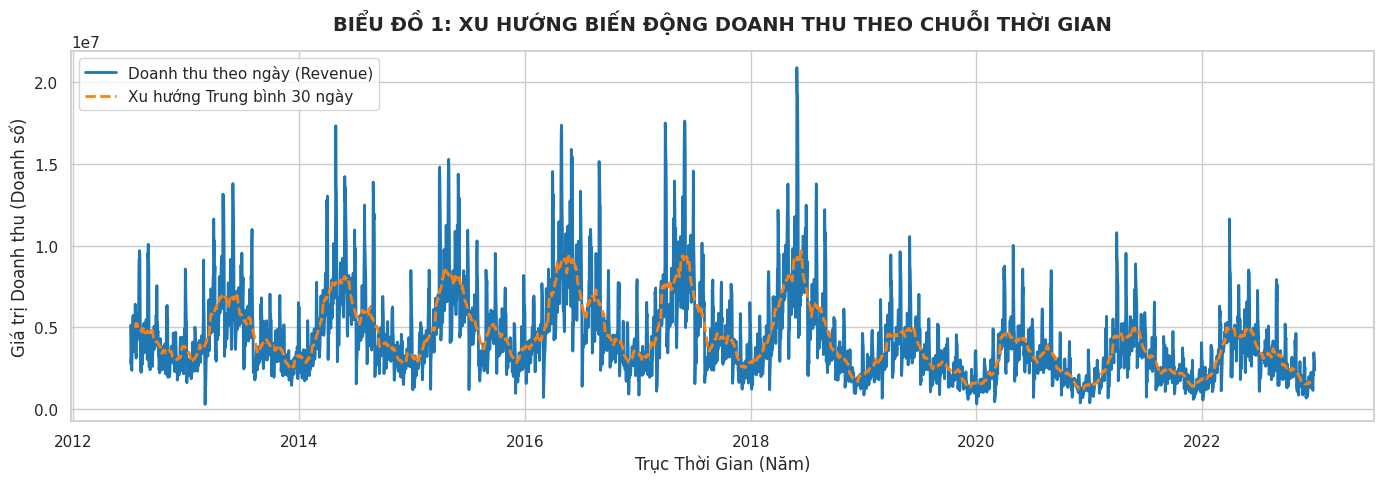

✅ Đã xuất biểu đồ 1: eda_xu_huong_doanh_thu.png


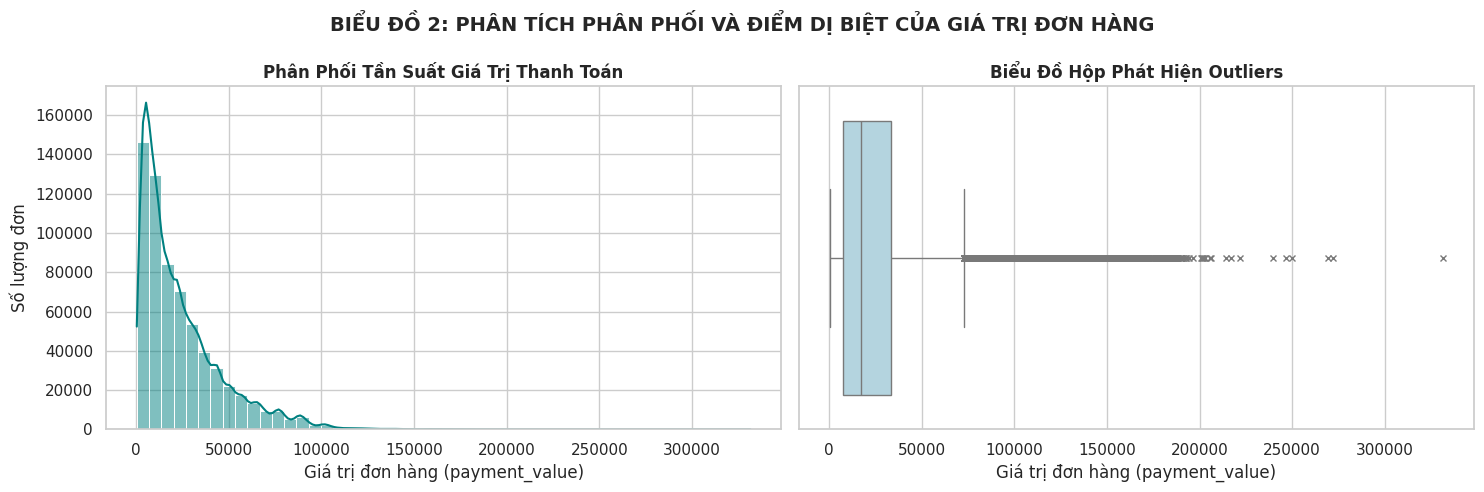

✅ Đã xuất biểu đồ 2: eda_phan_phoi_outliers.png


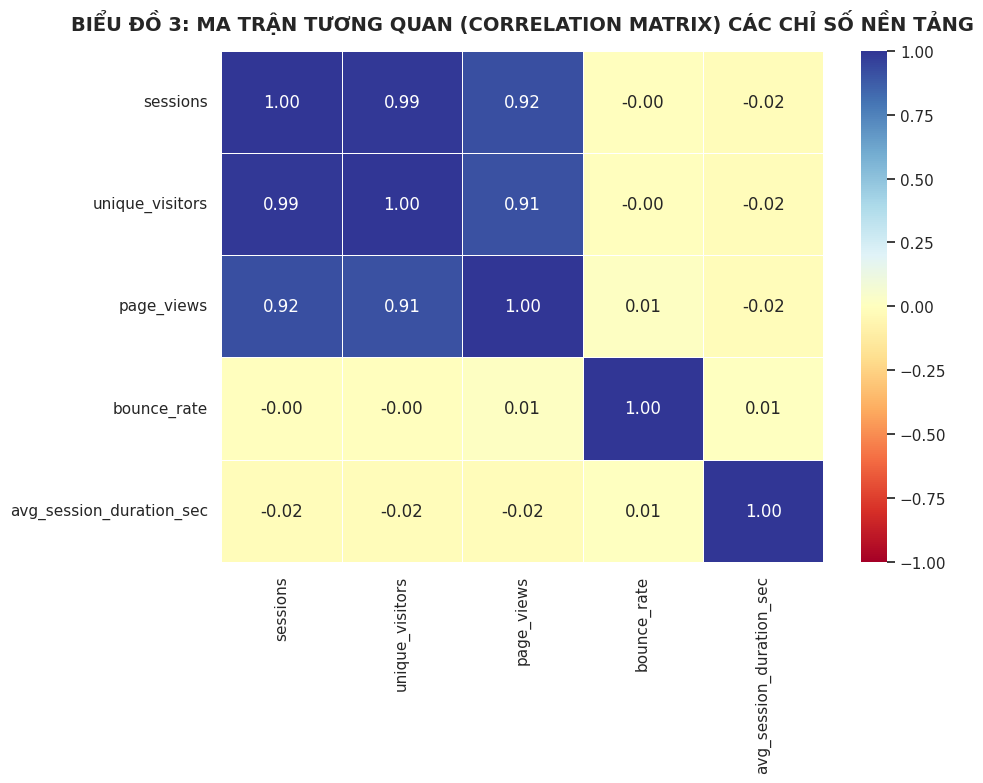

✅ Đã xuất biểu đồ 3: eda_ma_tran_tuong_quan.png


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cấu hình giao diện biểu đồ theo chuẩn báo cáo khoa học
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'DejaVu Sans' # Hoặc fonts hệ thống của bạn để tránh lỗi tiếng Việt
plt.rcParams['figure.figsize'] = (12, 6)

print("==================================================================")
print("BẮT ĐẦU CHẠY SCRIPT TRỰC QUAN HÓA KHÁM PHÁ DỮ LIỆU (EDA VISUALIZATION)")
print("==================================================================")

# ----------------------------------------------------------------
# 1. BIỂU ĐỒ CHUỖI THỜI GIAN: BIẾN ĐỘNG DOANH THU (Bảng sales.csv)
# ----------------------------------------------------------------
if 'sales' in locals() or 'sales' in globals():
    # Sao chép để tránh ghi đè dữ liệu gốc
    sales_ts = sales.copy()
    sales_ts['Date'] = pd.to_datetime(sales_ts['Date'])
    sales_ts = sales_ts.sort_values('Date')

    plt.figure(figsize=(14, 5))
    # Vẽ đường doanh thu
    plt.plot(sales_ts['Date'], sales_ts['Revenue'], color='#1f77b4', linewidth=2, label='Doanh thu theo ngày (Revenue)')

    # Tính đường trung bình trượt 30 ngày để thấy xu hướng rõ hơn (Trend line)
    sales_ts['Rolling_Mean'] = sales_ts['Revenue'].rolling(window=30, center=True).mean()
    plt.plot(sales_ts['Date'], sales_ts['Rolling_Mean'], color='#ff7f0e', linestyle='--', linewidth=2, label='Xu hướng Trung bình 30 ngày')

    plt.title('BIỂU ĐỒ 1: XU HƯỚNG BIẾN ĐỘNG DOANH THU THEO CHUỖI THỜI GIAN', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Trục Thời Gian (Năm)', fontsize=12)
    plt.ylabel('Giá trị Doanh thu (Doanh số)', fontsize=12)
    plt.legend(loc='upper left', fontsize=11)
    plt.tight_layout()
    plt.savefig('eda_xu_huong_doanh_thu.png', dpi=300) # Lưu ảnh chất lượng cao để chèn Word
    plt.show()
    print("✅ Đã xuất biểu đồ 1: eda_xu_huong_doanh_thu.png")

# ----------------------------------------------------------------
# 2. BIỂU ĐỒ HỘP (BOXPLOT): PHÁT HIỆN GIÁ TRỊ DỊ BIỆT (Outliers) CỦA ĐƠN HÀNG
# ----------------------------------------------------------------
if 'payments' in locals() or 'payments' in globals():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Biểu đồ phân phối Histogram của Giá trị đơn hàng
    sns.histplot(payments['payment_value'], bins=50, kde=True, color='teal', ax=ax1)
    ax1.set_title('Phân Phối Tần Suất Giá Trị Thanh Toán', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Giá trị đơn hàng (payment_value)')
    ax1.set_ylabel('Số lượng đơn')

    # Biểu đồ Hộp Boxplot để soi Outliers (Điểm dị biệt)
    sns.boxplot(x=payments['payment_value'], color='lightblue', ax=ax2,
                flierprops={"marker": "x", "markerfacecolor": "red", "markersize": 5})
    ax2.set_title('Biểu Đồ Hộp Phát Hiện Outliers', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Giá trị đơn hàng (payment_value)')

    plt.suptitle('BIỂU ĐỒ 2: PHÂN TÍCH PHÂN PHỐI VÀ ĐIỂM DỊ BIỆT CỦA GIÁ TRỊ ĐƠN HÀNG', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('eda_phan_phoi_outliers.png', dpi=300)
    plt.show()
    print("✅ Đã xuất biểu đồ 2: eda_phan_phoi_outliers.png")

# ----------------------------------------------------------------
# 3. MA TRẬN TƯƠNG QUAN: TÌM MỐI LIÊN HỆ GIỮA CÁC BIẾN SỐ (Heatmap)
# ----------------------------------------------------------------
if 'web_traffic' in locals() or 'web_traffic' in globals():
    # Lọc ra các cột số quan trọng trong bảng web traffic và kết hợp (nếu có)
    # Ở đây lấy ví dụ ma trận tương quan trực tiếp trên các chỉ số của web_traffic
    numeric_cols = web_traffic.select_dtypes(include=[np.number]).columns

    # Loại bỏ các cột ID nếu có lọt vào
    cols_to_corr = [c for c in numeric_cols if 'id' not in c.lower()]

    if len(cols_to_corr) > 1:
        corr_matrix = web_traffic[cols_to_corr].corr()

        plt.figure(figsize=(10, 8))
        # Vẽ biểu đồ nhiệt Heatmap
        sns.heatmap(corr_matrix, annot=True, cmap='RdYlBu', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)

        plt.title('BIỂU ĐỒ 3: MA TRẬN TƯƠNG QUAN (CORRELATION MATRIX) CÁC CHỈ SỐ NỀN TẢNG', fontsize=14, fontweight='bold', pad=15)
        plt.tight_layout()
        plt.savefig('eda_ma_tran_tuong_quan.png', dpi=300) # Lưu ảnh chất lượng cao để chèn Word
        plt.show()
        print("✅ Đã xuất biểu đồ 3: eda_ma_tran_tuong_quan.png")

### 1. **Data Type Conversion (Chuyển đổi kiểu dữ liệu)**

Many date columns are often loaded as generic objects. Converting them to datetime objects is crucial for time-series analysis and proper filtering.

In [11]:
print("==================================================================")
print("BẮT ĐẦU CHUYỂN ĐỔI KIỂU DỮ LIỆU ĐỐI VỚI CÁC CỘT NGÀY THÁNG")
print("==================================================================")

# List of common date column names across dataframes
date_cols = [
    'signup_date', 'snapshot_date', 'order_date', 'ship_date',
    'delivery_date', 'return_date', 'review_date', 'Date', 'date'
]

dataframes = {
    'customer': customer,
    'inventory': inventory,
    'orders': orders,
    'returns': returns,
    'reviews': reviews,
    'sales': sales,
    'shipments': shipments,
    'web_traffic': web_traffic
}

for df_name, df_obj in dataframes.items():
    print(f"\nĐang xử lý DataFrame: {df_name}")
    for col in date_cols:
        if col in df_obj.columns:
            original_dtype = df_obj[col].dtype
            df_obj[col] = pd.to_datetime(df_obj[col], errors='coerce')
            if df_obj[col].dtype != original_dtype:
                print(f"  - Cột '{col}' đã chuyển đổi từ {original_dtype} sang {df_obj[col].dtype}")
            else:
                print(f"  - Cột '{col}' (kiểu {original_dtype}) không cần chuyển đổi hoặc đã là datetime.")
    print(f"  Kiểm tra info sau chuyển đổi của {df_name}:")
    df_obj.info(verbose=False, memory_usage='deep')

print("\n✅ Hoàn tất chuyển đổi kiểu dữ liệu ngày tháng.")

BẮT ĐẦU CHUYỂN ĐỔI KIỂU DỮ LIỆU ĐỐI VỚI CÁC CỘT NGÀY THÁNG

Đang xử lý DataFrame: customer
  - Cột 'signup_date' đã chuyển đổi từ object sang datetime64[ns]
  Kiểm tra info sau chuyển đổi của customer:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121930 entries, 0 to 121929
Columns: 7 entries, customer_id to acquisition_channel
dtypes: datetime64[ns](1), int64(2), object(4)
memory usage: 29.0 MB

Đang xử lý DataFrame: inventory
  - Cột 'snapshot_date' đã chuyển đổi từ object sang datetime64[ns]
  Kiểm tra info sau chuyển đổi của inventory:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60247 entries, 0 to 60246
Columns: 17 entries, snapshot_date to month
dtypes: datetime64[ns](1), float64(3), int64(10), object(3)
memory usage: 16.8 MB

Đang xử lý DataFrame: orders
  - Cột 'order_date' đã chuyển đổi từ object sang datetime64[ns]
  Kiểm tra info sau chuyển đổi của orders:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 646945 entries, 0 to 646944
Columns: 8 entries, order_id to

BẮT ĐẦU TRỰC QUAN HÓA PHÂN PHỐI CỦA CÁC THUỘC TÍNH SỐ

--- Trực quan hóa phân phối trong products ---


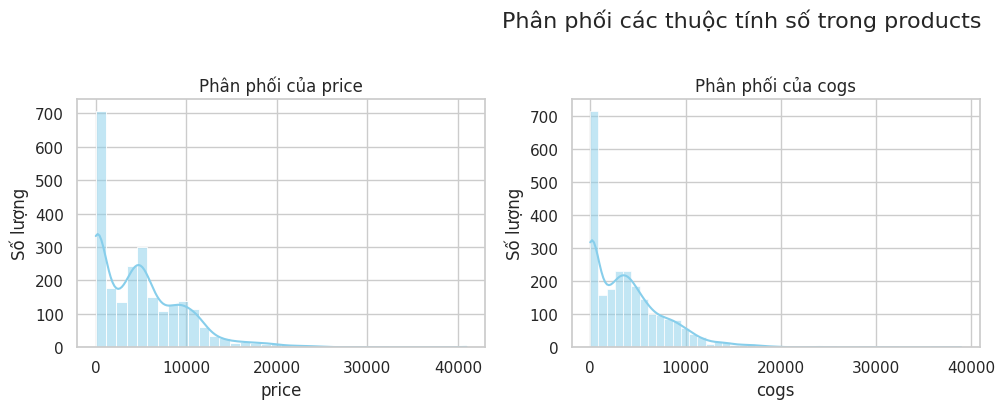


--- Trực quan hóa phân phối trong payments ---


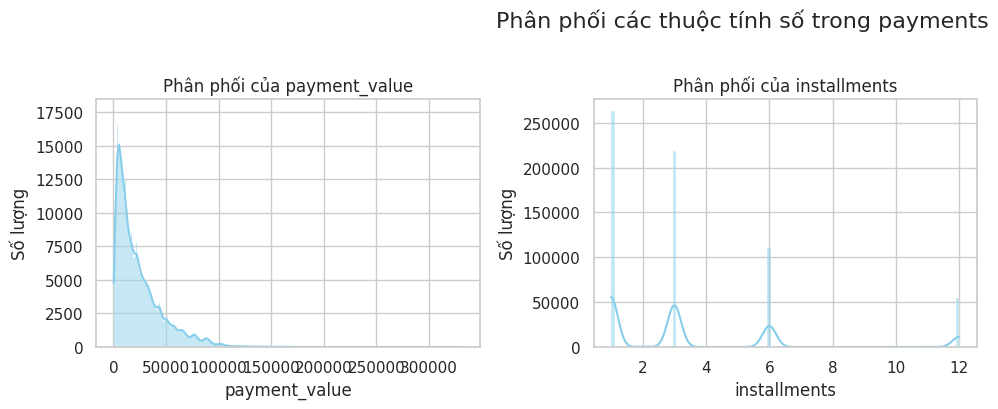


--- Trực quan hóa phân phối trong inventory ---


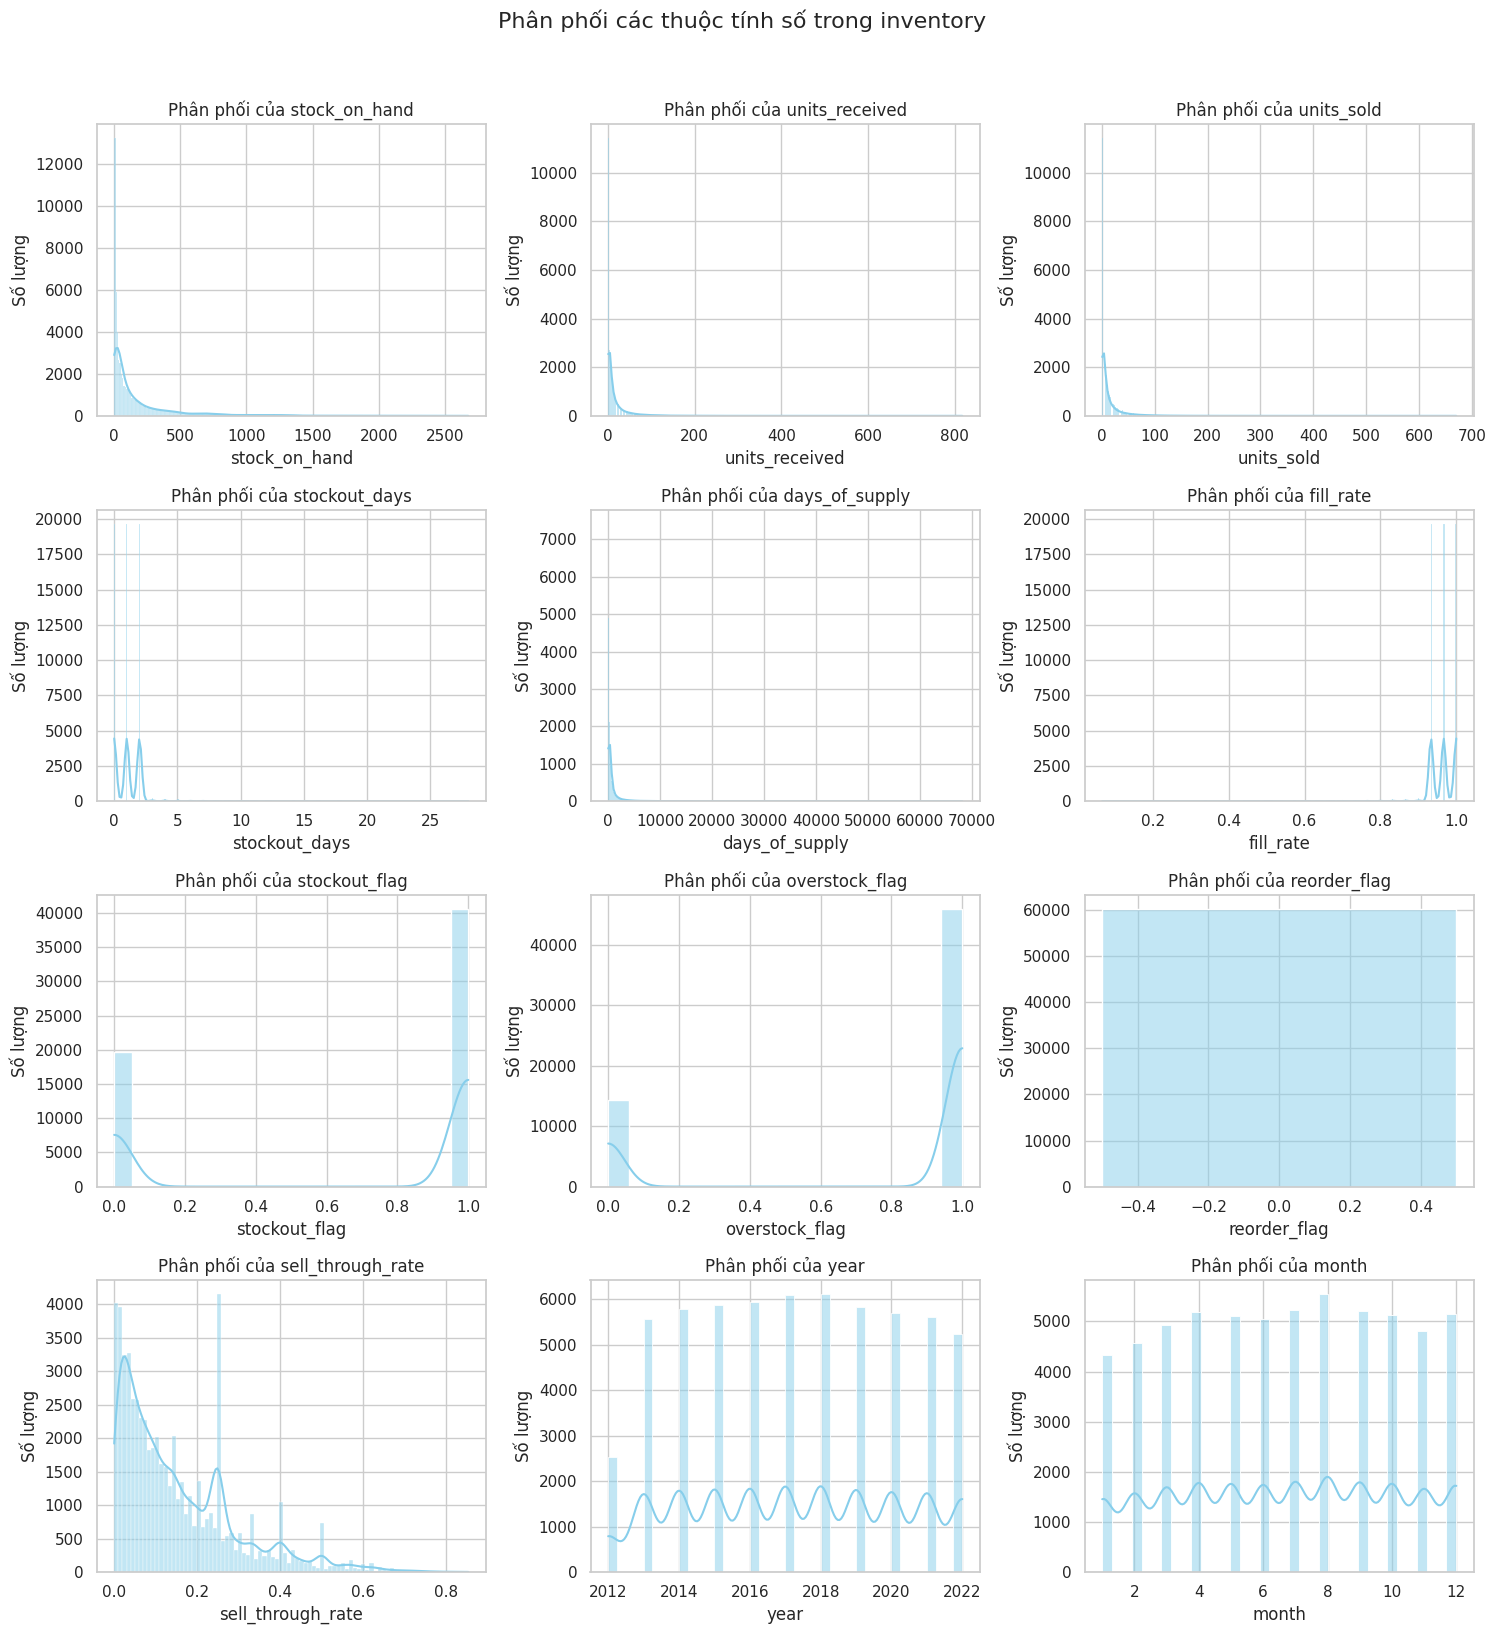


--- Trực quan hóa phân phối trong order_items ---


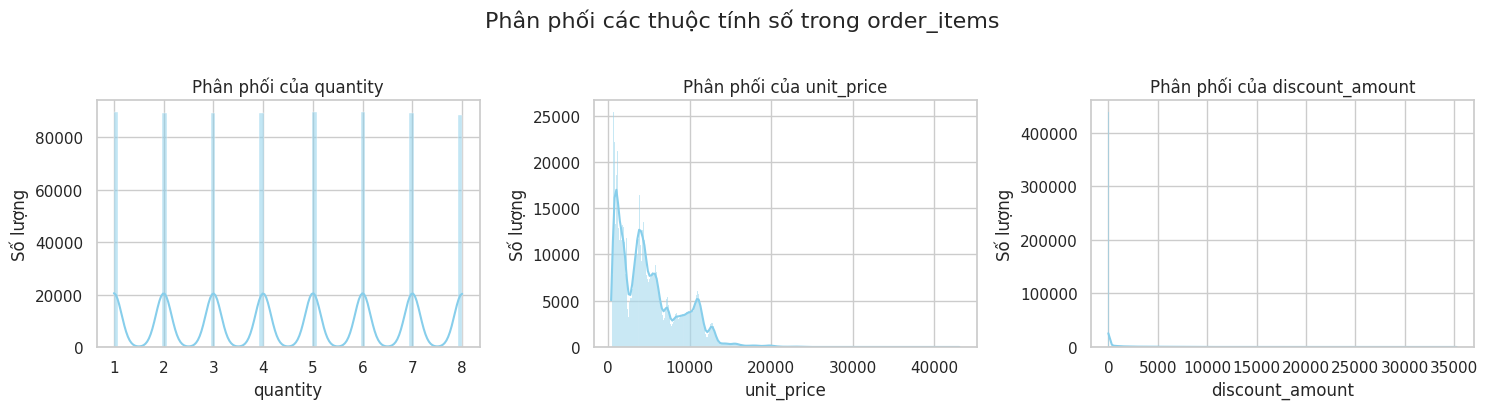


--- Trực quan hóa phân phối trong returns ---


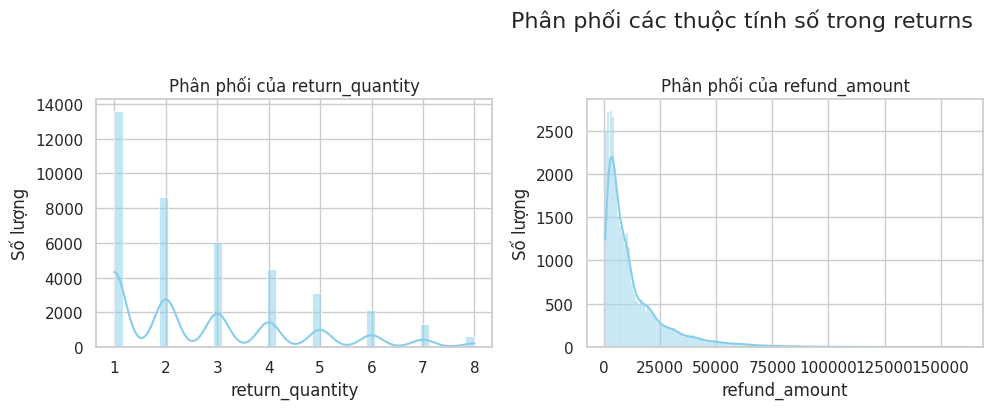


--- Trực quan hóa phân phối trong web_traffic ---


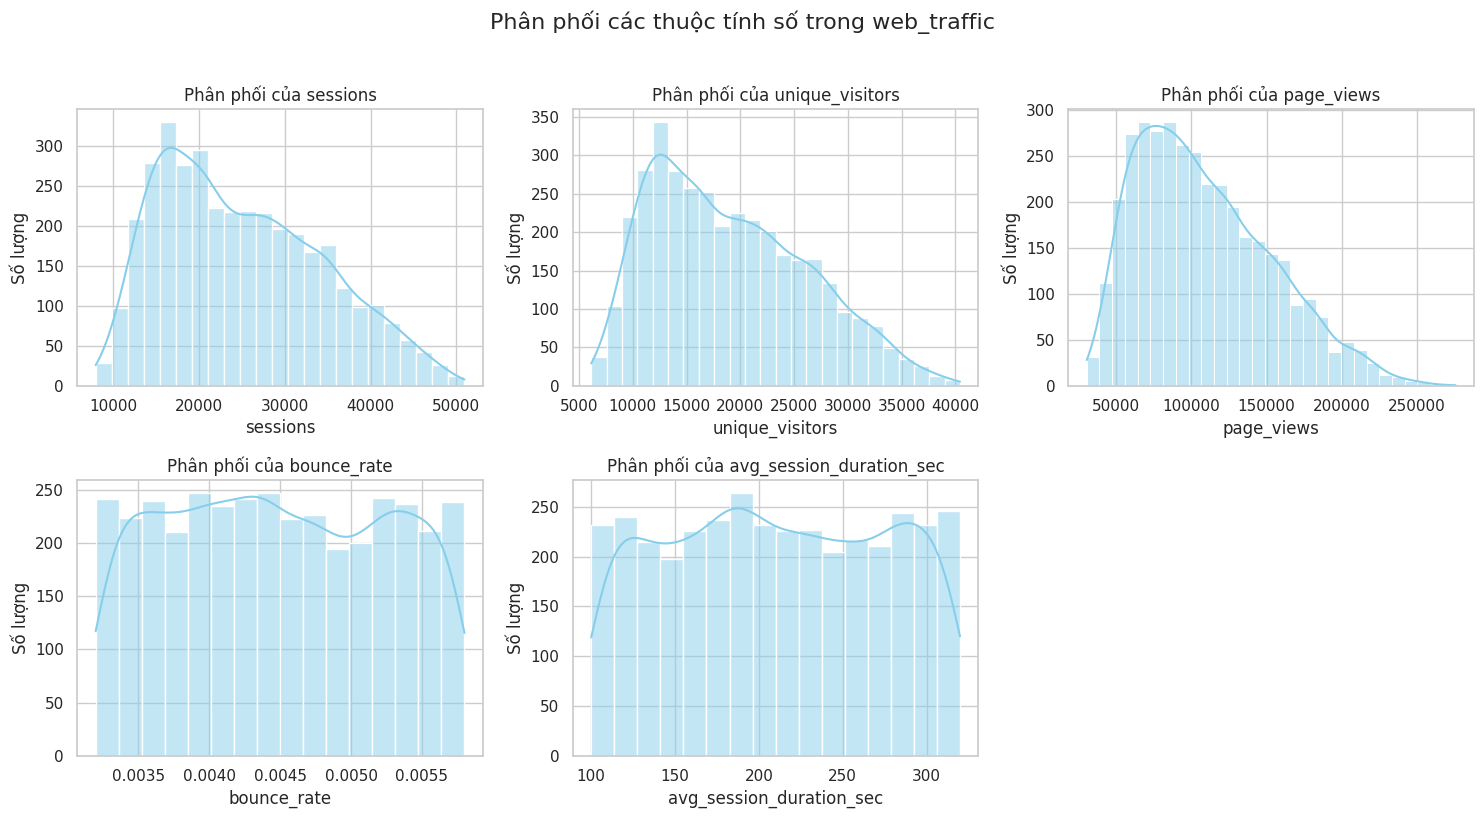


✅ Hoàn tất trực quan hóa phân phối các thuộc tính số.


In [16]:
print("==================================================================")
print("BẮT ĐẦU TRỰC QUAN HÓA PHÂN PHỐI CỦA CÁC THUỘC TÍNH SỐ")
print("==================================================================")

def plot_numerical_distributions(df, df_name, bins=50):
    print(f"\n--- Trực quan hóa phân phối trong {df_name} ---")

    # Exclude common ID columns from numerical distribution plots
    excluded_cols_for_plot = ['product_id', 'order_id', 'customer_id', 'review_id', 'zip']

    # Filter numerical columns, excluding the specified ID columns
    numerical_cols = [col for col in df.select_dtypes(include=np.number).columns
                      if col.lower() not in excluded_cols_for_plot]

    if len(numerical_cols) == 0:
        print(f"Không tìm thấy cột số nào để trực quan hóa trong {df_name} (sau khi loại trừ các cột ID).")
        return

    # Dynamic subplot grid
    n_cols = 3  # Number of columns for subplots
    n_rows = (len(numerical_cols) + n_cols - 1) // n_cols # Calculate rows needed

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
    axes = axes.flatten() # Flatten in case of single row/column

    for i, col in enumerate(numerical_cols):
        sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color='skyblue')
        axes[i].set_title(f'Phân phối của {col}', fontsize=12)
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Số lượng')

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle(f'Phân phối các thuộc tính số trong {df_name}', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

# Apply to relevant dataframes
plot_numerical_distributions(products, 'products')
plot_numerical_distributions(payments, 'payments')
plot_numerical_distributions(inventory, 'inventory')
plot_numerical_distributions(order_items, 'order_items')
plot_numerical_distributions(returns, 'returns')
plot_numerical_distributions(web_traffic, 'web_traffic')

print("\n✅ Hoàn tất trực quan hóa phân phối các thuộc tính số.")

In [25]:
print("Cài đặt thư viện hệ thống graphviz và các tệp phát triển...")
!apt-get update -qq > /dev/null
!apt-get install graphviz libgraphviz-dev pkg-config python3-dev -y

print("Cài đặt eralchemy2 và các phần phụ thuộc...")
!pip install eralchemy2

Cài đặt thư viện hệ thống graphviz và các tệp phát triển...
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
pkg-config is already the newest version (0.29.2-1ubuntu3).
python3-dev is already the newest version (3.10.6-1~22.04.1).
graphviz is already the newest version (2.42.2-6ubuntu0.1).
libgraphviz-dev is already the newest version (2.42.2-6ubuntu0.1).
The following packages were automatically installed and are no longer required:
  libbz2-dev libpkgconf3 libreadline-dev
Use 'apt autoremove' to remove them.
0 upgraded, 0 newly installed, 0 to remove and 30 not upgraded.
Cài đặt eralchemy2 và các phần phụ thuộc...


In [27]:
from eralchemy2 import render_er

# Cách 1: Vẽ từ chuỗi định nghĩa rút gọn giống như viết Markdown
markdown_schema = """
[Customers]
    *customer_id {label:"PRIMARY KEY"}
    customer_name
    email
    zip

[Orders]
    *order_id {label:"PRIMARY KEY"}
    customer_id
    order_date

Customers ||--o{ Orders
"""

with open("schema.er", "w") as f:
    f.write(markdown_schema)

# Xuất ra file ảnh
render_er("schema.er", "erd_output.png")

In [32]:
from eralchemy2 import render_er

markdown_schema = """
# ================================================================
# TABLES
# ================================================================

[Customers]
    *customer_id {label:"VARCHAR (PK)"}
    customer_unique_id
    customer_zip_code_prefix
    customer_city
    customer_state

[Geography]
    *zip {label:"INTEGER (PK)"}
    city
    state
    latitude
    longitude

[Orders]
    *order_id {label:"VARCHAR (PK)"}
    customer_id {label:"VARCHAR (FK)"}
    order_status
    order_purchase_timestamp
    order_approved_at
    order_delivered_carrier_date
    order_delivered_customer_date
    order_estimated_delivery_date

[Order_Items]
    *order_id {label:"VARCHAR (PK, FK)"}
    *order_item_id {label:"INTEGER (PK)"}
    product_id {label:"VARCHAR (FK)"}
    seller_id
    shipping_limit_date
    quantity
    unit_price
    price
    freight_value
    discount_amount

[Products]
    *product_id {label:"VARCHAR (PK)"}
    product_category_name
    product_name_length
    product_description_length
    product_photos_qty
    product_weight_g
    product_length_cm
    product_height_cm
    product_width_cm
    price
    cogs

[Payments]
    *order_id {label:"VARCHAR (PK, FK)"}
    payment_type
    payment_installments
    installments
    payment_value

[Shipments]
    *order_id {label:"VARCHAR (PK, FK)"}
    carrier_name
    delivery_status
    shipping_fee

[Reviews]
    *review_id {label:"VARCHAR (PK)"}
    order_id {label:"VARCHAR (FK)"}
    product_id {label:"VARCHAR (FK)"}
    customer_id {label:"VARCHAR (FK)"}
    review_score
    rating
    review_comment_title
    review_comment_message
    review_creation_date
    review_answer_timestamp

[Returns]
    *return_id {label:"VARCHAR (PK)"}
    order_id {label:"VARCHAR (FK)"}
    product_id {label:"VARCHAR (FK)"}
    return_reason
    return_quantity
    refund_amount

[Inventory]
    *product_id {label:"VARCHAR (PK, FK)"}
    *month {label:"VARCHAR (PK)"}
    stock_on_hand
    units_received
    units_sold
    stockout_days
    fill_rate
    sell_through_rate

[Promotions]
    *promo_id {label:"VARCHAR (PK)"}
    promo_name
    discount_rate
    start_date
    end_date

[Web_Traffic]
    *date {label:"DATE (PK)"}
    sessions
    unique_visitors
    bounce_rate
    avg_session_duration_sec
    conversion_rate

[Sales]
    *Date {label:"DATE (PK)"}
    Revenue
    COGS

# ================================================================
# RELATIONSHIPS
# ================================================================

Geography 1--* Customers

Customers 1--* Orders
Customers 1--* Reviews

Orders 1--* Order_Items
Orders 1--1 Payments
Orders 1--1 Shipments
Orders 1--* Reviews
Orders 1--* Returns

Products 1--* Order_Items
Products 1--* Inventory
Products 1--* Reviews
Products 1--* Returns

Web_Traffic 1--1 Sales
"""

with open("schema.er", "w", encoding="utf-8") as f:
    f.write(markdown_schema)

print("⚙️ Rendering ERD...")

try:
    render_er("schema.er", "erd_output.png")
    print("✅ ERD created successfully: erd_output.png")

except Exception as e:
    print(f"❌ Error: {e}")
    print("Make sure Graphviz is installed.")

⚙️ Rendering ERD...
✅ ERD created successfully: erd_output.png
